# LOADEING in DATAREAMES from FILES

# FOR CVS(Comma Separate File )

In [27]:
import pandas as pd
Coffee = pd.read_csv('./warmup-data/Coffee.csv')
#Coffee = pd.read_csv('https://raw.githubusercontent.com/KeithGalli/complete-pandas-tutorial/refs/heads/master/warmup-data/coffee.csv')
# this is to fetch data from GITHUB repo

# ->CSV files are the most popular file format but its very huge in size
# ->other file format 1:Feather 2:parquet which have same data but less in size

In [28]:
Coffee # whole data
#Coffee.head() #first 5 rows 
#print(Coffee) #also whole data but in raw form
Coffee.tail(5) #last 5 rows
#Coffee.sample() #show data randomly without any order


,Day,Coffee Type,Units Sold
9,Friday,Latte,35
10,Saturday,Espresso,45
11,Saturday,Latte,35
12,Sunday,Espresso,45
13,Sunday,Latte,35


In [29]:
Coffee.head()

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35


<!-- FOR PARQUET FILES -->

In [30]:
result = pd.read_parquet('./data/results.parquet')

# ->Parquet is a column storage foemat that is optimized for distributing  a large datasets in small size

In [31]:
result.head()

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal
0,1912.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,17.0,True,None
1,1912.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jean Montariol,NaN,False,None
2,1920.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,32.0,True,None
3,1920.0,Summer,Tennis,"Doubles, Mixed (Olympic)",Jean-François Blanchy,1,FRA,Jeanne Vaussard,8.0,True,None
4,1920.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jacques Brugnon,4.0,False,None


# FOR EXCLE FILE 

In [32]:
#import pandas as pd
olympics_data = pd.read_excel('./data/olympics-data.xlsx')
#olympics_data = pd.read_excel('./data/olympics-data.xlsx',sheet_name="results")
#OR WITH SHEET NAME ALSO

In [33]:
olympics_data.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


<!-- .LOC & .ILOC IN PANDAS -->

# ->.loc &.iloc both are used for selecting specific subsets of data.
# ->their purpose access & manipulating a specific part of data.
# SYNTAX:
<!--loc=df.loc[#rows-idx,clomn-idx]
    iloc=df.iloc[#rows-idx,clomn-idx] -->

In [34]:
Coffee.loc[0] #only row 0
Coffee.loc[[0,1,2]] #first 3 rows
Coffee.loc[0:5] #slicing in Python
Coffee.loc[0:] #0 to len of row
Coffee.loc[:5] #star to 5 rows
Coffee.loc[0:5,["Day","Units Sold"]] #rows,column

,Day,Units Sold
0,Monday,25
1,Monday,15
2,Tuesday,30
3,Tuesday,20
4,Wednesday,35
5,Wednesday,25


<!-- .ILOC ONLY USES INDEX VALUE
Coffee.iloc[0:5,["Day","Units Sold"]] ERROR -->

In [35]:
#Coffee.index = Coffee["Day"] #convt idx=0,1 to monday,tuesday

In [36]:
Coffee.loc["Monday":"Tuesday"] #for .loc convert idx to days
Coffee.iloc[0:5, [0, 2]] #for .iloc its only idx value

,Day,Units Sold
0,Monday,25
1,Monday,15
2,Tuesday,30
3,Tuesday,20
4,Wednesday,35


# IF WE WANT TO CHANGE ANY VALUE IN THE DATA

In [37]:
Coffee

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25
6,Thursday,Espresso,40
7,Thursday,Latte,30
8,Friday,Espresso,45
9,Friday,Latte,35


In [38]:
#let suppose whe have to change the value of units sold ind=1
Coffee.loc[1,"Units Sold"] =10
Coffee.loc[1:2,"Units Sold"] =10 #idx 1,2 val=10

In [39]:
Coffee.head()

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,10
2,Tuesday,Espresso,10
3,Tuesday,Latte,20
4,Wednesday,Espresso,35


# SORTING VALUES IN PANDAS
# ASCENDING & DESCENDING ORDER

In [40]:
Coffee.sort_values("Units Sold") #ASCENDING
Coffee.sort_values("Units Sold",ascending=False) #DESCENDING

,Day,Coffee Type,Units Sold
10,Saturday,Espresso,45
8,Friday,Espresso,45
12,Sunday,Espresso,45
6,Thursday,Espresso,40
4,Wednesday,Espresso,35
11,Saturday,Latte,35
13,Sunday,Latte,35
9,Friday,Latte,35
7,Thursday,Latte,30
0,Monday,Espresso,25


# FILTERING DATA IN PANDAS

In [41]:
#import pandas as pd
bios = pd.read_csv("data/bios.csv")

In [42]:
bios.head() #all olympics data bios
bios.tail() #end of bios data
bios.loc[bios['height_cm'] > 215] #FILTERING DATA only >215cm (we can also do bios[bios...])
bios.loc[bios['height_cm'] > 215,['name','height_cm']] #filter only name and height
bios[bios['height_cm'] > 215][['name','height_cm']] #short way to write
#WHEN WE COMBINE THINGS AND THEN FILTER OUT
bios.loc[(bios['height_cm'] > 215) & (bios['born_country']=='USA')]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
5781,5804,Tommy Burleson,1952-02-24,Crossnore,North Carolina,USA,United States,223.0,102.0,NaN
6722,6755,Shaquille O'Neal,1972-03-06,Newark,New Jersey,USA,United States,216.0,137.0,NaN
6937,6972,David Robinson,1965-08-06,Key West,Florida,USA,United States,216.0,107.0,NaN
123850,126093,Tyson Chandler,1982-10-02,Hanford,California,USA,United States,216.0,107.0,NaN


# FILTER DATA |STRING OPERATION, REGULAR EXPRESSION(regex)

In [174]:
# bios[bios['name'].str.contains("Keith")] #all name(Keiths) appear
# bios[bios['name'].str.contains("Keith|Patrick")] #in this all kisth & Patrick appear
# bios[bios['born_country'].isin(["PAK","IND","USA"])] #it tell if pak or ind exist in col(born_counrty) 
bios[bios['born_country'].isin(["PAK","IND","USA"]) & (bios['name'].str.startswith(("Keith","Ali")))] #combining two conditions to filter out

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,Category,height_rank
279,280,Ali Athar Fyzee,1883-08-28,Mumbai,Maharashtra,IND,India,NaN,NaN,1963-11-03,Heavyweight,NaN
9738,9793,Alistair Wilson,1939-08-20,Kolkata (Calcutta),West Bengal,IND,Great Britain,175.0,73.0,NaN,Midweight,58380.5
13028,13100,Alison Dunlap,1969-07-27,Denver,Colorado,USA,United States,168.0,56.0,NaN,Lightweight,83975.0
19030,19163,Ali Dara,1915-04-01,Faisalabad,Punjab,PAK,India Pakistan,NaN,NaN,1981-01-16,Heavyweight,NaN
29008,29222,Aliane Baquerot,1978-11-23,New York,New York,USA,United States,NaN,NaN,NaN,Heavyweight,NaN
40212,40520,Alison Townley,1965-09-06,Minneapolis,Minnesota,USA,United States,178.0,73.0,NaN,Midweight,46966.0
50616,50975,Alice Bridges,1916-07-19,Waterville,Maine,USA,United States,NaN,NaN,2011-05-05,Heavyweight,NaN
50743,51102,Alice Lord,1902-02-04,Philadelphia,Pennsylvania,USA,United States,165.0,NaN,2000-07-13,Heavyweight,91849.5
50929,51288,Keith Carter,1924-08-30,Akron,Ohio,USA,United States,NaN,NaN,2013-05-03,Heavyweight,NaN
51185,51544,Keith Russell,1948-01-15,Mesa,Arizona,USA,United States,188.0,73.0,NaN,Midweight,13590.5


# FILTERING DATA | QUERY FUNCTIONS

In [44]:
#another easy way to filter data
bios.query('born_country == "PAK"') #for country
bios.query('born_country == "PAK"and born_city =="Multan"') #for city

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
288,289,Mohammed Sleem,1892-01-14,Multan,Punjab,PAK,India,NaN,NaN,NaN
19169,19304,Raghbir Singh Bhola,1927-08-18,Multan,Punjab,PAK,India,183.0,67.0,2019-01-21


# ADDING/REMOVING COLUMN IN PANDAS

In [45]:
Coffee['price'] = 4.99 #add a new colmn 

In [46]:
Coffee.head()

,Day,Coffee Type,Units Sold,price
0,Monday,Espresso,25,4.99
1,Monday,Latte,10,4.99
2,Tuesday,Espresso,10,4.99
3,Tuesday,Latte,20,4.99
4,Wednesday,Espresso,35,4.99


# BUT IF WE WANT TO ADD SEPARATE PRICE 
# WE USE NUMPY(LIBRARAY) HERE

In [47]:
import numpy as np
Coffee['New_Price']= np.where(Coffee['Coffee Type'] == 'Latte',5.99,3.99)

In [ ]:
Coffee.head(5)

,Day,Coffee Type,Units Sold,price,New_Price
0,Monday,Espresso,25,4.99,3.99
1,Monday,Latte,10,4.99,5.99
2,Tuesday,Espresso,10,4.99,3.99
3,Tuesday,Latte,20,4.99,5.99
4,Wednesday,Espresso,35,4.99,3.99


# NOW WE HAVE DO DELETE/REMOVE THE 'price' colmn

In [49]:
Coffee.drop(columns=['price'], inplace=True, errors='ignore') #now the price column del
#Here inplace=Ture is use to actual data update & errors to re_run this code without any error
Coffee.head(5)


,Day,Coffee Type,Units Sold,New_Price
0,Monday,Espresso,25,3.99
1,Monday,Latte,10,5.99
2,Tuesday,Espresso,10,3.99
3,Tuesday,Latte,20,5.99
4,Wednesday,Espresso,35,3.99


# HERE REVENUE COLMN ADD & ALSO RENAME METHOD

In [50]:
Coffee['Revenue'] = Coffee['Units Sold'] * Coffee['New_Price']
Coffee.head(5) #here new colm 'revenue' add
# Coffee.rename(columns={"revenue": "Revenue"}, inplace=True)
# Coffee.head(5) #here I rename 'revenue' to 'Revenue'


,Day,Coffee Type,Units Sold,New_Price,Revenue
0,Monday,Espresso,25,3.99,99.75
1,Monday,Latte,10,5.99,59.90
2,Tuesday,Espresso,10,3.99,39.90
3,Tuesday,Latte,20,5.99,119.80
4,Wednesday,Espresso,35,3.99,139.65


# MAKE A NEW BIOS FILE & ADD DATA ACCORDING TO YOURS

In [51]:
bios_new = bios.copy() #In this case new bios made and the original bios data not affected

# NEW COLUMNS ADD IN DATA

In [52]:
bios_new['first_name'] = bios_new['name'].str.split(' ').str[0]

In [53]:
bios_new #adding new column at last of the table
bios_new.query('first_name == "John" ') 

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,first_name
78,79,John Pius Boland,1870-09-16,Dublin,Dublin,IRL,Great Britain,NaN,NaN,1958-03-17,John
375,376,John McDonald,1965-05-28,Halifax,Nova Scotia,CAN,Canada,183.0,74.0,NaN,John
569,571,John Bridges,1852-03-26,Horsham,England,GBR,Great Britain,NaN,NaN,1925-02-12,John
579,581,John Keyworth,1859-05-09,Lincoln,England,GBR,Great Britain,NaN,NaN,1954-04-24,John
583,585,John Penrose,1850-05-05,Littleham,England,GBR,Great Britain,NaN,NaN,1932-04-21,John
...,...,...,...,...,...,...,...,...,...,...,...
139710,143187,John Gimson,1983-03-11,Leicester,England,GBR,Great Britain,NaN,NaN,NaN,John
142300,145902,John Ume,1996-08-19,NaN,NaN,NaN,Papua New Guinea,NaN,NaN,NaN,John
142874,146504,John Hakizimana,1996-10-26,NaN,NaN,NaN,Rwanda,NaN,NaN,NaN,John
143806,147462,John John Florence,1992-10-18,Honolulu,Hawaiʻi,USA,United States,185.0,84.0,NaN,John


# ADD NEW COLUMN FOR BIRTH YEAR

In [54]:
bios_new['born_datetime'] = pd.to_datetime(bios_new['born_date'])

In [55]:
bios_new['born_year'] = bios_new['born_datetime'].dt.year #Only date year appear
bios_new[['name','born_year']] #now we get new file having data name and born year 

,name,born_year
0,Jean-François Blanchy,1886.0
1,Arnaud Boetsch,1969.0
2,Jean Borotra,1898.0
3,Jacques Brugnon,1895.0
4,Albert Canet,1878.0
...,...,...
145495,Polina Luchnikova,2002.0
145496,Valeriya Merkusheva,1999.0
145497,Yuliya Smirnova,1998.0
145498,André Foussard,1899.0


In [56]:
bios_new.to_csv('./data/bios_new.csv',index=False)
#now a new file is created in the folder

# NOW APPLY IF ELSE CONITION TO Categorize Athlete

In [57]:
def categorize_athlete(row):
    if row['height_cm'] < 175 and row["weight_kg"] < 70:
        return 'Lightweight'
    elif row['height_cm'] < 190 and row["weight_kg"] < 90:
        return 'Midweight'
    else:
        return 'Heavyweight'

bios['Category'] = bios.apply(categorize_athlete, axis=1)

In [58]:
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,Category
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,Heavyweight
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,Midweight
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,Midweight
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,Lightweight
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,Heavyweight


# MERGING & CONCATENATION DATA IN PANDAS

In [59]:
nocs = pd.read_csv('./data/noc_regions.csv')

In [ ]:
nocs.head()

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


# MERGING TWO dataset BIOS & NOCS

In [61]:
bios_new = pd.merge(bios,nocs, left_on='born_country',right_on='NOC' ,how='left')

->Here we are merging data of "nocs" column in "bios" data.
->Left Joins(DBMS) concept are use here.. where all the data of bios + nocs data merge.
->how='left' means bios all data and nocs only matching data merge.

# ->Also we replace the name "region " to "born_county_full"

In [62]:
bios_new.rename(columns={'region':'born_county_full'}, inplace=True)

In [63]:
bios_new.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC_x,height_cm,weight_kg,died_date,Category,NOC_y,born_county_full,notes
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,Heavyweight,FRA,France,NaN
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,Midweight,FRA,France,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,Midweight,FRA,France,NaN
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,Lightweight,FRA,France,NaN
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,Heavyweight,GBR,UK,NaN


# Here NOC_x=old data & NOC_y=new data due to same column name

In [64]:
usa = bios[bios['born_country']== 'USA'].copy()
gbr = bios[bios['born_country']== 'GBR'].copy()

# Here 'usa' & 'gbr' two different DataFrames taking values from 'bios' and copy it to itsa related vari_name = usa & gbr

In [66]:
new_df = pd.concat([usa ,gbr])

# Now we merge to DF into a new_df
# IMP:
# :Merge = It joins data on the basis of common column.
# 2:concat = It joins rows or column

In [70]:
new_df.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,Category
54,55,Monique Javer,1967-07-22,Burlingame,California,USA,Great Britain,177.0,64.0,NaN,Midweight
960,964,Xóchitl Escobedo,1968-09-17,West Covina,California,USA,Mexico,170.0,60.0,NaN,Lightweight
961,965,Angélica Gavaldón,1973-10-03,El Centro,California,USA,Mexico,160.0,54.0,NaN,Lightweight
1231,1238,Bert Schneider,1897-07-01,Cleveland,Ohio,USA,Canada,NaN,NaN,1986-02-20,Heavyweight
1345,1352,Laura Berg,1975-01-06,Santa Fe Springs,California,USA,United States,168.0,61.0,NaN,Lightweight


## ANOTHER EXAMPLE OF MERGE

In [75]:
combined_pd = pd.merge(result,bios, on="athlete_id",how='left')

In [77]:
combined_pd.head(3)

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,...,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,Category
0,1912.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,17.0,True,...,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,Heavyweight
1,1912.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jean Montariol,NaN,False,...,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,Heavyweight
2,1920.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,32.0,True,...,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,Heavyweight


## HANDLING NULL VALUES IN PANDAS

In [103]:
Coffee.loc[[1,2],'Units Sold'] = np.nan
Coffee.loc[[0],'Units Sold'] =15
Coffee.head() #First we empty some data

,Day,Coffee Type,Units Sold,New_Price,Revenue
0,Monday,Espresso,15.0,3.99,99.75
1,Monday,Latte,NaN,5.99,59.90
2,Tuesday,Espresso,NaN,3.99,39.90
3,Tuesday,Latte,20.0,5.99,119.80
4,Wednesday,Espresso,35.0,3.99,139.65


In [115]:
# Coffee.fillna(1000) #(MHD-1) but not recommended
# Coffee.fillna(Coffee['Units Sold'].mean()) #(MHD-2) it gives you the mean of the empty data
Coffee['Units Sold']= Coffee['Units Sold'].interpolate() #interpol = only works when 1st and last val have some data

In [118]:
# Coffee['Units Sold'] = Coffee['Units Sold'].round(1)
Coffee.head()

,Day,Coffee Type,Units Sold,New_Price,Revenue
0,Monday,Espresso,15.0,3.99,99.75
1,Monday,Latte,16.7,5.99,59.90
2,Tuesday,Espresso,18.3,3.99,39.90
3,Tuesday,Latte,20.0,5.99,119.80
4,Wednesday,Espresso,35.0,3.99,139.65


## AGGREGATING DATA IN PANDAS

In [131]:
bios['born_city'].value_counts()
#bios[bios['born_country']=='PAK']['born_region'].value_counts()

born_city
Budapest           1378
Moskva (Moscow)     883
Oslo                708
Stockholm           629
Praha (Prague)      600
                   ... 
Kirovgrad             1
Pereiaslav            1
Podgornyy             1
Kudepsta              1
Furmanov              1
Name: count, Length: 22368, dtype: int64

In [127]:
Coffee.groupby(['Coffee Type']).agg({
    'Units Sold':'sum',
    'New_Price':'mean'})

,Units Sold,New_Price
Coffee Type,,
Espresso,243.3,3.99
Latte,196.7,5.99


## ->groupby = make groups of coffee eg: latte(10,20,30..so on).
## ->agg = every group do some calculation

In [129]:
pivot = Coffee.pivot(
    columns='Coffee Type',
    index='Day',
    values='Revenue')

In [145]:
pivot.head() #make data easy and short
# pivot.loc[['Monday','Tuesday'],'Latte']
# pivot.sum()
# pivot.sum(axis=1) # axis-1=rows

Coffee Type,Espresso,Latte
Day,,
Friday,179.55,209.65
Monday,99.75,59.90
Saturday,179.55,209.65
Sunday,179.55,209.65
Thursday,159.60,179.70


# ADVANCED FUNCTIONALITY IN PANDAS
# .shift(), .rank(), .roll(), .cumsum()

In [148]:
Coffee.head(1)

,Day,Coffee Type,Units Sold,New_Price,Revenue
0,Monday,Espresso,15.0,3.99,99.75


In [149]:
Coffee['Yesterday_Revenue'] = Coffee['Revenue'].shift(2) #Also do shift(-2)
Coffee.head() #It shift the revnn value 2 step down in "yest_reven"

,Day,Coffee Type,Units Sold,New_Price,Revenue,Yesterday_Revenue
0,Monday,Espresso,15.0,3.99,99.75,NaN
1,Monday,Latte,16.7,5.99,59.90,NaN
2,Tuesday,Espresso,18.3,3.99,39.90,99.75
3,Tuesday,Latte,20.0,5.99,119.80,59.90
4,Wednesday,Espresso,35.0,3.99,139.65,39.90


In [152]:
bios['height_rank'] = bios['height_cm'].rank(ascending=False)
bios.sort_values(['height_rank'])

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,Category,height_rank
89070,89782,Yao Ming,1980-09-12,Xuhui District,Shanghai,CHN,People's Republic of China,226.0,141.0,NaN,Heavyweight,1.0
6978,7013,Arvydas Sabonis,1964-12-19,Kaunas,Kaunas,LTU,Lithuania Soviet Union,223.0,122.0,NaN,Heavyweight,2.5
5781,5804,Tommy Burleson,1952-02-24,Crossnore,North Carolina,USA,United States,223.0,102.0,NaN,Heavyweight,2.5
5673,5696,Gunther Behnke,1963-01-19,Leverkusen,Nordrhein-Westfalen,GER,Germany,221.0,114.0,NaN,Heavyweight,5.0
89075,89787,Roberto Dueñas,1975-11-01,Madrid,Madrid,ESP,Spain,221.0,137.0,NaN,Heavyweight,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
145490,149217,Sin Ye-Chan,1995-06-13,NaN,NaN,NaN,Republic of Korea,NaN,NaN,NaN,Heavyweight,NaN
145491,149218,Matthew Wepke,1989-12-05,NaN,NaN,NaN,Jamaica,NaN,NaN,NaN,Heavyweight,NaN
145492,149219,Carlos García-Ordóñez,1927-04-24,La Habana (Havana),Ciudad de La Habana,CUB,Cuba,NaN,NaN,2019-11-24,Heavyweight,NaN
145493,149220,Landysh Falyakhova,1998-08-31,Dva Polya Artash,Respublika Tatarstan,RUS,ROC,NaN,NaN,NaN,Heavyweight,NaN


In [153]:
Coffee.head(2)

,Day,Coffee Type,Units Sold,New_Price,Revenue,Yesterday_Revenue
0,Monday,Espresso,15.0,3.99,99.75,NaN
1,Monday,Latte,16.7,5.99,59.90,NaN


In [ ]:
Coffee['Cumulative_New_Price'] = Coffee['New_Price'].cumsum()
Coffee.head(4) #Cumulative_sum (Prob & stats) subject

,Day,Coffee Type,Units Sold,New_Price,Revenue,Yesterday_Revenue,Cumulative_New_Price
0,Monday,Espresso,15.0,3.99,99.75,NaN,3.99
1,Monday,Latte,16.7,5.99,59.90,NaN,9.98
2,Tuesday,Espresso,18.3,3.99,39.90,99.75,13.97
3,Tuesday,Latte,20.0,5.99,119.80,59.90,19.96


## NEW FUNCTIONALITY IN PANDAS

In [158]:
result_numpy = pd.read_csv('./data/results.csv')
result_arrow = pd.read_csv('./data/results.csv',engine='pyarrow', dtype_backend='pyarrow')

## ->engine='pyarrow' => read csv by using PyArrow engine(much faster)
## ->dtype_backend='pyarrow' => the datatype of DF also use PyArrow 

In [161]:
result_numpy["as"].str.contains('Ali')

0         False
1         False
2         False
3         False
4         False
          ...  
308403    False
308404    False
308405    False
308406    False
308407    False
Name: as, Length: 308408, dtype: bool

In [162]:
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,Category,height_rank
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,Heavyweight,NaN
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,Midweight,27597.5
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,Midweight,27597.5
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,Lightweight,83975.0
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,Heavyweight,NaN


In [164]:
import pandas as pd
import numpy as np

data = {
    'athlete_id': [1, 2, 3, 4, 5, 6, 7, 8],
    'name': ['Jean-François Blanchy', 'Arnaud Boetsch', 'Jean Borotra', 
              'Jacques Brugnon', 'Albert Canet', 'Marie Dubois', 
              'Hans Müller', 'Sofia Rossi'],
    'born_country': ['FRA', 'FRA', 'FRA', 'FRA', 'GBR', 'FRA', 'GER', 'ITA'],
    'NOC': ['France', 'France', 'France', 'France', 'France', 'France', 'Germany', 'Italy'],
    'height_cm': [np.nan, 183.0, 183.0, 168.0, np.nan, 165.0, 190.0, 172.0],
    'weight_kg': [np.nan, 76.0, 76.0, 64.0, np.nan, 58.0, 88.0, 65.0],
    'Category': ['Heavyweight', 'Midweight', 'Midweight', 'Lightweight', 
                 'Heavyweight', 'Lightweight', 'Heavyweight', 'Midweight'],
    'died_date': ['1960-10-02', np.nan, '1994-07-17', '1978-03-20', 
                  '1930-07-25', np.nan, '2010-05-01', np.nan]
}

practice_df = pd.DataFrame(data)
practice_df.head()

,athlete_id,name,born_country,NOC,height_cm,weight_kg,Category,died_date
0,1,Jean-François Blanchy,FRA,France,NaN,NaN,Heavyweight,1960-10-02
1,2,Arnaud Boetsch,FRA,France,183.0,76.0,Midweight,NaN
2,3,Jean Borotra,FRA,France,183.0,76.0,Midweight,1994-07-17
3,4,Jacques Brugnon,FRA,France,168.0,64.0,Lightweight,1978-03-20
4,5,Albert Canet,GBR,France,NaN,NaN,Heavyweight,1930-07-25


In [166]:
# Average height by Category
practice_df.pivot_table(values='height_cm', index='Category', aggfunc='mean')

# Average height & weight by Category, split by NOC
practice_df.pivot_table(values=['height_cm', 'weight_kg'], index='Category', columns='NOC', aggfunc='mean')

# Count of athletes by Category and NOC
# practice_df.pivot_table(values='athlete_id', index='Category', columns='NOC', aggfunc='count')

height_cm                weight_kg              
NOC            France Germany  Italy    France Germany Italy
Category                                                    
Heavyweight       NaN   190.0    NaN       NaN    88.0   NaN
Lightweight     166.5     NaN    NaN      61.0     NaN   NaN
Midweight       183.0     NaN  172.0      76.0     NaN  65.0

## NOW USING BIOS DATA AND MAKE A "BAR-GRAPH" OF ATHELETES HEIGHT

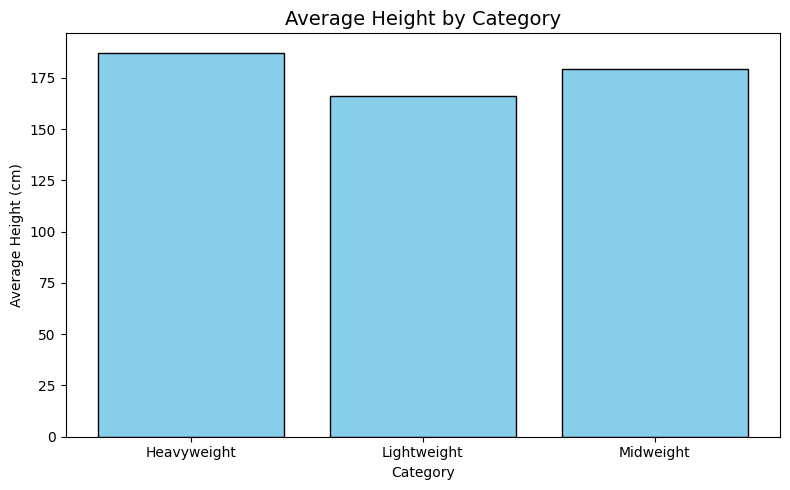

In [173]:

import matplotlib.pyplot as plt

# Average height by Category (grouping)
avg_height = bios.groupby('Category')['height_cm'].mean()

# Bar graph banate hain
plt.figure(figsize=(8, 5))
plt.bar(avg_height.index, avg_height.values, color='skyblue', edgecolor='black')

plt.title('Average Height by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Average Height (cm)')
plt.tight_layout()

plt.show()